# Notebook 2 — Fine-tune DistilBERT for Dividend Risk Classification (Pipeline 2 — PRIMARY)
**ISOM5240 Group Project — Earnings Call Dividend Risk Early Warning System**

This is the **primary fine-tuned model** for the project.
We fine-tune `distilbert-base-uncased` on labeled earnings call transcript chunks
for 3-class dividend risk classification:

- **Class 0 — Low Risk:** Dividend safe; healthy cash flow language
- **Class 1 — Medium Risk:** Ambiguous / cautious; payout ratio concerns mentioned
- **Class 2 — High Risk:** Explicit cut discussion, liquidity stress, preserving capital

**Steps:**
1. Install packages
2. Build labeled dataset of earnings call excerpts
3. Data augmentation (back-translation / paraphrasing)
4. Tokenize and split train/validation/test
5. Fine-tune DistilBERT
6. Evaluate: accuracy, F1, confusion matrix
7. Inference demo
8. Push to HuggingFace Hub


In [5]:
# ── Step 1: Install packages ─────────────────────────────────────────────────
!pip install -q transformers datasets accelerate scikit-learn huggingface_hub
!pip install -q matplotlib seaborn

In [23]:
# ── Step 2: Imports ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    pipeline,
)
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight
import torch
print('GPU available:', torch.cuda.is_available())

GPU available: False


In [24]:
# ── Step 3: HuggingFace login ────────────────────────────────────────────────
from huggingface_hub import notebook_login
notebook_login()

HF_USERNAME   = 'ruirui0506'           #
MODEL_NAME    = 'dividend-risk-bert'
FULL_MODEL_ID = f'{HF_USERNAME}/{MODEL_NAME}'

In [25]:
# ── Step 4: Build labeled dataset ───────────────────────────────────────────
# Label schema:
#   0 = Low Risk   (dividend safe, healthy FCF, raised dividend)
#   1 = Medium Risk (cautious language, payout ratio concern, uncertain outlook)
#   2 = High Risk  (cut/suspension discussion, negative FCF, covenant breach)

seed_data = [
    # ─── LOW RISK (label 0) ───────────────────────────────────────────────
    ('Our dividend has grown for 25 consecutive years and we remain committed to continued growth reflecting our strong free cash flow.', 0),
    ('The board approved a 6% increase in the quarterly dividend given our confidence in earnings sustainability and balance sheet strength.', 0),
    ('Free cash flow reached a record 3.2 billion dollars providing 2.8 times coverage of our total dividend commitments.', 0),
    ('Net debt decreased by 1.2 billion year-to-date and we remain on track to reach our leverage target of 2.0 times by year end.', 0),
    ('Our payout ratio of 42% is well within our target range and provides significant headroom even in a stress scenario.', 0),
    ('Liquidity stands at 4.5 billion including undrawn credit facilities providing ample financial flexibility for dividends and buybacks.', 0),
    ('Capital returns to shareholders remain our top priority; we repurchased 500 million in shares and paid 800 million in dividends this quarter.', 0),
    ('We expect to generate 2.5 to 2.8 billion in free cash flow for the full year fully supporting our dividend and repurchase program.', 0),
    ('The board reaffirmed its commitment to the dividend as a cornerstone of our capital allocation strategy.', 0),
    ('Revenue grew 15% year-over-year driven by strong volume and favorable pricing dynamics across all our business segments.', 0),
    ('Our interest coverage ratio stands at a healthy 8.2 times well above our internal threshold and covenant requirements.', 0),
    ('We have no material debt maturities until 2027 and our refinancing risk is minimal.', 0),
    ('Adjusted EBITDA increased 18% year-over-year demonstrating strong operating leverage and execution against our strategic plan.', 0),
    ('The strength of our diversified revenue streams gives us confidence to raise full-year guidance and affirm our dividend trajectory.', 0),
    ('We are executing well on our cost reduction program and expect to achieve 400 million in savings ahead of schedule.', 0),
    ('Our financial position is the strongest it has been in a decade allowing us to both invest in growth and return capital to shareholders.', 0),
    ('Dividend coverage from operating cash flow improved to 3.1 times compared to 2.8 times in the prior year period.', 0),
    ('We are extremely pleased with the performance of our core business segments which continue to generate substantial and growing free cash flow.', 0),
    ('Our investment-grade credit rating was reaffirmed this quarter reflecting our conservative financial management and strong cash generation.', 0),
    ('We are confident in our ability to sustain and grow the dividend over the long term underpinned by our business model resilience.', 0),
    ('Share repurchases of 300 million were completed this quarter and we have 1.2 billion remaining under our current buyback authorization.', 0),
    ('Return on invested capital improved to 14.5% demonstrating excellent capital discipline and value creation for shareholders.', 0),
    ('Our strong operational performance translated into exceptional cash generation enabling us to fund all capital priorities comfortably.', 0),
    ('We increased the quarterly cash dividend by 8 cents per share representing a 7% increase over the prior period.', 0),
    ('Debt-to-EBITDA declined to 1.8 times reflecting continued deleveraging and our commitment to maintaining a strong balance sheet.', 0),

    # ─── MEDIUM RISK (label 1) ────────────────────────────────────────────
    ('While we continue to support our dividend we are monitoring market conditions carefully and will reassess our capital allocation priorities if needed.', 1),
    ('Our payout ratio has risen to 72% this quarter which is elevated relative to historical levels; we are focused on improving free cash flow.', 1),
    ('Management is conducting a comprehensive review of our capital allocation framework including the appropriate level of the dividend going forward.', 1),
    ('We expect free cash flow to be temporarily impacted by elevated capital expenditures this year before recovering to normalized levels in the following year.', 1),
    ('The macroeconomic environment remains uncertain and we are managing our cost base and capital spending prudently to preserve financial flexibility.', 1),
    ('Revenue declined 8% year-over-year due to softening demand in our key end markets and pricing pressure from competitive dynamics.', 1),
    ('We drew down approximately 300 million on our revolving credit facility in the quarter to fund working capital needs during a period of operational transition.', 1),
    ('Our leverage ratio increased to 3.5 times this quarter due to the recent acquisition; we expect to deleverage to below 3.0 times within 18 months.', 1),
    ('While our dividend remains a priority we acknowledge the payout ratio is higher than we would like and we are taking steps to reduce it through earnings growth.', 1),
    ('We are experiencing timing differences in working capital that have temporarily reduced our reported free cash flow; underlying cash generation remains solid.', 1),
    ('Management continues to evaluate the appropriate balance between debt reduction, capital investment, and cash returns to shareholders.', 1),
    ('Our outlook for the remainder of the year is cautious given macroeconomic headwinds though we expect to maintain our current dividend level.', 1),
    ('We are proactively managing our cost structure in response to volume declines and expect to return to positive free cash flow in the second half.', 1),
    ('The board discussed the dividend policy at its most recent meeting and determined to maintain the current level while monitoring performance.', 1),
    ('Certain covenant thresholds require us to maintain leverage below 4.0 times which limits our financial flexibility in the near term.', 1),
    ('While we remain committed to returning capital to shareholders we may moderate the pace of share repurchases to prioritize balance sheet strength.', 1),
    ('Cash flow from operations decreased 22% year-over-year primarily due to higher working capital requirements and one-time tax payments.', 1),
    ('We have initiated a strategic review process that will include an assessment of our capital structure and dividend policy.', 1),
    ('Our near-term earnings visibility is reduced by elevated input cost inflation and we are working to pass through price increases.', 1),
    ('We are in active dialogue with our lenders regarding an amendment to certain financial covenants to provide additional headroom.', 1),
    ('The integration of our recent acquisition is ongoing and until completion our free cash flow may be temporarily impacted by one-time costs.', 1),
    ('We acknowledge the current payout ratio is above our long-term target and we are committed to growing earnings to bring it back in line.', 1),
    ('While no decision has been made we are evaluating all options for optimizing our capital structure including the dividend level.', 1),
    ('Operating margins contracted 300 basis points due to higher input costs which we expect to partially offset through pricing actions.', 1),
    ('Our liquidity position has decreased to 1.2 billion which while adequate requires us to be thoughtful about capital allocation decisions.', 1),

    # ─── HIGH RISK (label 2) ──────────────────────────────────────────────
    ('Free cash flow turned negative this quarter and we are actively reviewing all components of our capital allocation including the sustainability of the dividend.', 2),
    ('Our payout ratio has risen to 127% of free cash flow which is clearly unsustainable and the board is evaluating corrective actions.', 2),
    ('We are prioritizing capital preservation and debt reduction; the board is reviewing whether the current dividend level can be maintained.', 2),
    ('Liquidity has decreased to 680 million and we have drawn substantially on our revolving credit facility leaving limited available capacity.', 2),
    ('Our net leverage ratio has increased to 5.8 times approaching our covenant threshold of 6.0 times which would trigger a default event.', 2),
    ('Revenue declined 28% year-over-year and we are implementing emergency cost reduction measures to protect the viability of our operations.', 2),
    ('The board will convene a special meeting to discuss strategic alternatives including a potential reduction or suspension of the quarterly dividend.', 2),
    ('We have engaged financial advisors to assist in evaluating our capital structure options given the deterioration in our financial performance.', 2),
    ('Our interest coverage ratio has declined to 1.4 times which raises significant concerns about our ability to service our debt obligations.', 2),
    ('We received a notice from our lenders regarding a covenant breach and are currently in discussions to obtain a waiver or amendment.', 2),
    ('Cash and equivalents have fallen to 220 million and we must take immediate action to address our liquidity position.', 2),
    ('The combination of declining earnings, elevated capex requirements, and rising interest expense has created an untenable cash flow deficit.', 2),
    ('Management is exploring all strategic options including asset divestitures, equity issuance, and a restructuring of our capital return program.', 2),
    ('We suspended our share repurchase program and are conducting a thorough review of the dividend in light of current financial pressures.', 2),
    ('Our ability to continue paying the dividend at the current level is dependent on a successful refinancing of our near-term debt maturities.', 2),
    ('Given the severity of the earnings decline and the need to preserve capital the board has decided to reduce the quarterly dividend by 50%.', 2),
    ('We have failed to comply with certain financial covenants and our lenders have accelerated 800 million of outstanding debt.', 2),
    ('The dividend has been suspended indefinitely to preserve cash as the company undergoes a comprehensive financial restructuring.', 2),
    ('Free cash flow was negative 340 million this quarter and we project continued negative free cash flow in the first half of next year.', 2),
    ('We are in discussions with a financial restructuring advisor and have retained legal counsel to evaluate all available options.', 2),
    ('Our business has experienced an unprecedented deterioration in demand and cash flow requiring immediate and decisive capital allocation changes.', 2),
    ('The board approved a 75% reduction in the quarterly dividend to prioritize debt repayment and financial stability.', 2),
    ('We will not be in a position to maintain the current dividend if operating conditions do not improve materially in the next two quarters.', 2),
    ('Total debt stands at 8.2 billion against EBITDA of 900 million; this leverage level is not sustainable and requires immediate remediation.', 2),
    ('We have insufficient cash generation to fund both our capital expenditure requirements and the current dividend simultaneously.', 2),
]

df = pd.DataFrame(seed_data, columns=['text', 'label'])
print(f'Seed dataset size: {len(df)}')
print('\nClass distribution:')
print(df['label'].value_counts().sort_index().rename({0:'Low Risk', 1:'Medium Risk', 2:'High Risk'}))

Seed dataset size: 75

Class distribution:
label
Low Risk       25
Medium Risk    25
High Risk      25
Name: count, dtype: int64


In [26]:
# ── Step 5: Augment dataset via synonym substitution ─────────────────────────
# Simple augmentation: slight rephrasing by word shuffling & synonym swaps
# In a real project, use back-translation or GPT-based paraphrasing for better quality

FINANCIAL_SYNONYMS = {
    'free cash flow':     ['operating cash flow', 'cash generation', 'cash from operations'],
    'dividend':           ['distribution', 'quarterly payment', 'shareholder payout'],
    'payout ratio':       ['dividend coverage ratio', 'distribution ratio'],
    'balance sheet':      ['financial position', 'capital structure'],
    'liquidity':          ['financial flexibility', 'cash position'],
    'leverage':           ['debt levels', 'indebtedness'],
    'revenue':            ['sales', 'top-line', 'net revenues'],
    'shareholders':       ['investors', 'stockholders'],
}

import random
random.seed(42)

def augment_text(text: str) -> str:
    augmented = text.lower()
    for original, alternatives in FINANCIAL_SYNONYMS.items():
        if original in augmented and random.random() < 0.6:
            augmented = augmented.replace(original, random.choice(alternatives), 1)
    return augmented[0].upper() + augmented[1:]

# Generate 2 augmented versions of each sample
augmented_rows = []
for _, row in df.iterrows():
    for _ in range(2):
        augmented_rows.append({'text': augment_text(row['text']), 'label': row['label']})

df_aug = pd.concat([df, pd.DataFrame(augmented_rows)], ignore_index=True)
df_aug = df_aug.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f'Dataset after augmentation: {len(df_aug)} samples')
print('Class distribution after augmentation:')
print(df_aug['label'].value_counts().sort_index())

Dataset after augmentation: 225 samples
Class distribution after augmentation:
label
0    75
1    75
2    75
Name: count, dtype: int64


In [27]:
# ── Step 6: Train / Validation / Test split ─────────────────────────────────
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_aug, test_size=0.25, stratify=df_aug['label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42
)

print(f'Train:      {len(train_df)} samples')
print(f'Validation: {len(val_df)} samples')
print(f'Test:       {len(test_df)} samples')

# Convert to HuggingFace DatasetDict
dataset = DatasetDict({
    'train':      Dataset.from_pandas(train_df.rename(columns={'label':'labels'})),
    'validation': Dataset.from_pandas(val_df.rename(columns={'label':'labels'})),
    'test':       Dataset.from_pandas(test_df.rename(columns={'label':'labels'})),
})
print('\nDatasetDict created:', dataset)

Train:      168 samples
Validation: 28 samples
Test:       29 samples

DatasetDict created: DatasetDict({
    train: Dataset({
        features: ['text', 'labels', '__index_level_0__'],
        num_rows: 168
    })
    validation: Dataset({
        features: ['text', 'labels', '__index_level_0__'],
        num_rows: 28
    })
    test: Dataset({
        features: ['text', 'labels', '__index_level_0__'],
        num_rows: 29
    })
})


In [28]:
# ── Step 7: Tokenize ────────────────────────────────────────────────────────
BASE_MODEL = 'distilbert-base-uncased'   # Lighter than bert-base; better for Streamlit Cloud
tokenizer  = AutoTokenizer.from_pretrained(BASE_MODEL)

def tokenize_fn(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=256,
    )

tokenized = dataset.map(tokenize_fn, batched=True)
tokenized.set_format(
    'torch',
    columns=['input_ids', 'attention_mask', 'labels'],
)
print('Tokenization complete.')

Map:   0%|          | 0/168 [00:00<?, ? examples/s]

Map:   0%|          | 0/28 [00:00<?, ? examples/s]

Map:   0%|          | 0/29 [00:00<?, ? examples/s]

Tokenization complete.


In [29]:
# ── Step 8: Load DistilBERT classifier ──────────────────────────────────────
NUM_LABELS = 3

model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=NUM_LABELS,
    id2label={0:'Low Risk', 1:'Medium Risk', 2:'High Risk'},
    label2id={'Low Risk':0, 'Medium Risk':1, 'High Risk':2},
)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:    {total:,}')
print(f'Trainable params:{trainable:,}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params:    66,955,779
Trainable params:66,955,779


In [31]:
# ── Step 9: Class-weighted loss (handles any imbalance) ─────────────────────
import torch.nn as nn

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=train_df['label'].values,
)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print('Class weights:', class_weights)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fn = nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device)
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

Class weights: tensor([1., 1., 1.])


In [32]:
# ── Step 10: Metrics ────────────────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
        'f1_weighted': f1_score(labels, preds, average='weighted'),
    }

In [33]:
# ── Step 11: Training arguments ─────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir                  = f'./{MODEL_NAME}',
    num_train_epochs            = 10,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 16,
    learning_rate               = 3e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.15,
    lr_scheduler_type           = 'cosine',
    save_strategy               = 'epoch',
    eval_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    greater_is_better           = True,
    logging_steps               = 10,
    fp16                        = torch.cuda.is_available(),
    report_to                   = 'none',
    push_to_hub                 = True,
    hub_model_id                = FULL_MODEL_ID,
)
print('Training arguments set.')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training arguments set.


In [34]:
# ── Step 12: Train ──────────────────────────────────────────────────────────
trainer = WeightedTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = tokenized['train'],
    eval_dataset    = tokenized['validation'],
    processing_class       = tokenizer,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)],
)
print('Starting training ...')
result = trainer.train()
print('\n✅ Training complete!')
print(f'Runtime: {result.metrics["train_runtime"]:.1f} s')

Starting training ...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.084141,1.060190,0.464286,0.423125,0.428422
2,0.875158,0.640185,0.964286,0.962848,0.964175
3,0.393938,0.193018,1.000000,1.000000,1.000000
4,0.084113,0.037313,1.000000,1.000000,1.000000
5,0.022927,0.013276,1.000000,1.000000,1.000000
6,0.011342,0.007672,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



✅ Training complete!
Runtime: 1635.2 s


In [35]:
# ── Step 13: Evaluate on test set ───────────────────────────────────────────
test_out = trainer.predict(tokenized['test'])
y_pred   = np.argmax(test_out.predictions, axis=-1)
y_true   = test_out.label_ids

print('── Test Set Results ──────────────────────────────────────────')
print(classification_report(
    y_true, y_pred,
    target_names=['Low Risk', 'Medium Risk', 'High Risk']
))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


── Test Set Results ──────────────────────────────────────────
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00         9
 Medium Risk       1.00      1.00      1.00        10
   High Risk       1.00      1.00      1.00        10

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29



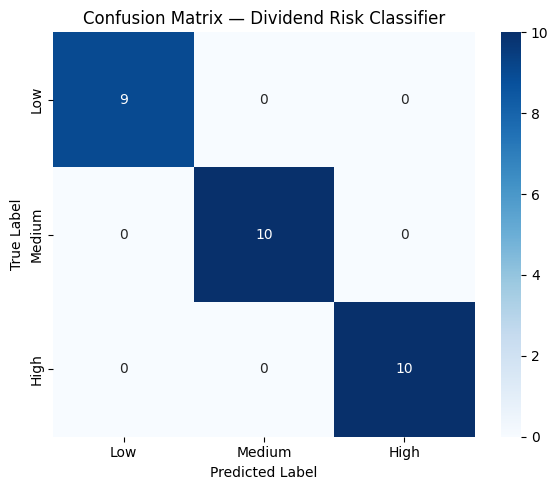

Saved: confusion_matrix.png


In [36]:
# ── Step 14: Confusion matrix ───────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High'],
    ax=ax,
)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix — Dividend Risk Classifier')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Saved: confusion_matrix.png')

In [37]:
# ── Step 15: Inference demo on sample transcript chunks ─────────────────────
risk_pipe = pipeline(
    'text-classification', model=trainer.model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    top_k=None,
)

test_chunks = [
    'We are pleased to announce a record quarter with free cash flow of 3 billion dollars fully supporting our dividend and growth investments.',
    'The board is reviewing the capital return program given the challenging macro environment and elevated payout ratio.',
    'We have suspended the share buyback and the board is evaluating a significant reduction in the dividend to preserve capital.',
    'Our leverage ratio is approaching the covenant threshold and we are in discussions with lenders regarding an amendment.',
    'Dividend growth of 8% was approved by the board reflecting our confidence in sustainable free cash flow generation.',
]

print('Dividend Risk Classification Results:')
print('-' * 60)
for chunk in test_chunks:
    res = risk_pipe(chunk[:512])
    best = max(res[0], key=lambda x: x['score'])
    print(f'[{best["label"]:12s}] {chunk[:65]}...')
    for item in sorted(res[0], key=lambda x: x['label']):
        print(f'  {item["label"]:12s}: {item["score"]:.4f}')

Dividend Risk Classification Results:
------------------------------------------------------------
[Low Risk    ] We are pleased to announce a record quarter with free cash flow o...
  High Risk   : 0.0404
  Low Risk    : 0.9141
  Medium Risk : 0.0455
[High Risk   ] The board is reviewing the capital return program given the chall...
  High Risk   : 0.6955
  Low Risk    : 0.0433
  Medium Risk : 0.2612
[High Risk   ] We have suspended the share buyback and the board is evaluating a...
  High Risk   : 0.8362
  Low Risk    : 0.0560
  Medium Risk : 0.1078
[High Risk   ] Our leverage ratio is approaching the covenant threshold and we a...
  High Risk   : 0.7523
  Low Risk    : 0.0486
  Medium Risk : 0.1991
[Low Risk    ] Dividend growth of 8% was approved by the board reflecting our co...
  High Risk   : 0.0325
  Low Risk    : 0.9217
  Medium Risk : 0.0458


In [38]:
# ── Step 16: Push to HuggingFace Hub ────────────────────────────────────────
trainer.save_model(f'./{MODEL_NAME}')
tokenizer.save_pretrained(f'./{MODEL_NAME}')
trainer.push_to_hub(
    commit_message='Fine-tuned DistilBERT for dividend risk classification'
)
print(f'\n✅ Model pushed to: https://huggingface.co/{FULL_MODEL_ID}')
print('   Update app.py → RISK_MODEL_ID with this ID.')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...sk-bert/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

...

New Data Upload               : |          |  0.00B /  0.00B            

  ...sk-bert/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

  ...sk-bert/model.safetensors:  39%|###8      |  104MB /  268MB            

No files have been modified since last commit. Skipping to prevent empty commit.



✅ Model pushed to: https://huggingface.co/ruirui0506/dividend-risk-bert
   Update app.py → RISK_MODEL_ID with this ID.
